# Week 15 — Friday (Jul 7): PROJECT — Image-to-Image Translation + Gradio Demo

## Project Goal
Bring together everything from this week (conditional GANs, PatchGAN, Pix2Pix) into one complete,
demoable pipeline, applied to a **custom dataset** — Fashion-MNIST — instead of the plain digits
used earlier in the week. The trained generator is then wrapped in a **Gradio** web demo so a user
can sketch an edge map and see the model translate it into a garment image live.

## Pipeline
1. **Custom dataset** — Fashion-MNIST (10 clothing categories), turned into a paired
   edge→garment dataset with Sobel edge detection (same recipe as Wednesday, new domain)
2. **Model** — U-Net-lite generator + PatchGAN discriminator (Pix2Pix)
3. **Train** — adversarial + L1 loss, same recipe as Wednesday's Pix2Pix notebook
4. **Evaluate** — qualitative edge→garment grid + per-class inspection
5. **Demo** — wrap the trained generator in a `gradio.Interface` so a user can draw a sketch and
   get a live translation


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Week 15 - Friday: PROJECT - Image-to-Image Translation + Gradio Demo')

PyTorch 2.12.0+cpu | Device: cpu
Week 15 - Friday: PROJECT - Image-to-Image Translation + Gradio Demo


## Step 1: Custom Dataset — Fashion-MNIST Edge→Garment Pairs

Fashion-MNIST swaps digits for 10 clothing categories (T-shirt, trouser, pullover, dress, coat,
sandal, shirt, sneaker, bag, ankle boot) — same 28×28 grayscale format as MNIST, but a genuinely
different, more textured domain, making it a good "custom dataset" stand-in for the real
edges→shoes / edges→handbags datasets Pix2Pix was originally demonstrated on.


  0%|          | 0.00/26.4M [00:00<?, ?B/s]

  0%|          | 32.8k/26.4M [00:00<01:44, 253kB/s]

  0%|          | 65.5k/26.4M [00:00<01:51, 237kB/s]

  0%|          | 98.3k/26.4M [00:00<01:54, 229kB/s]

  1%|          | 229k/26.4M [00:00<00:55, 469kB/s] 

...

 93%|█████████▎| 4.13M/4.42M [00:01<00:00, 3.36MB/s]

100%|██████████| 4.42M/4.42M [00:01<00:00, 2.40MB/s]

  0%|          | 0.00/5.15k [00:00<?, ?B/s]

100%|██████████| 5.15k/5.15k [00:00<00:00, 9.78MB/s]

Fashion-MNIST paired dataset: 1500 samples | classes: 10 | size (32, 32)


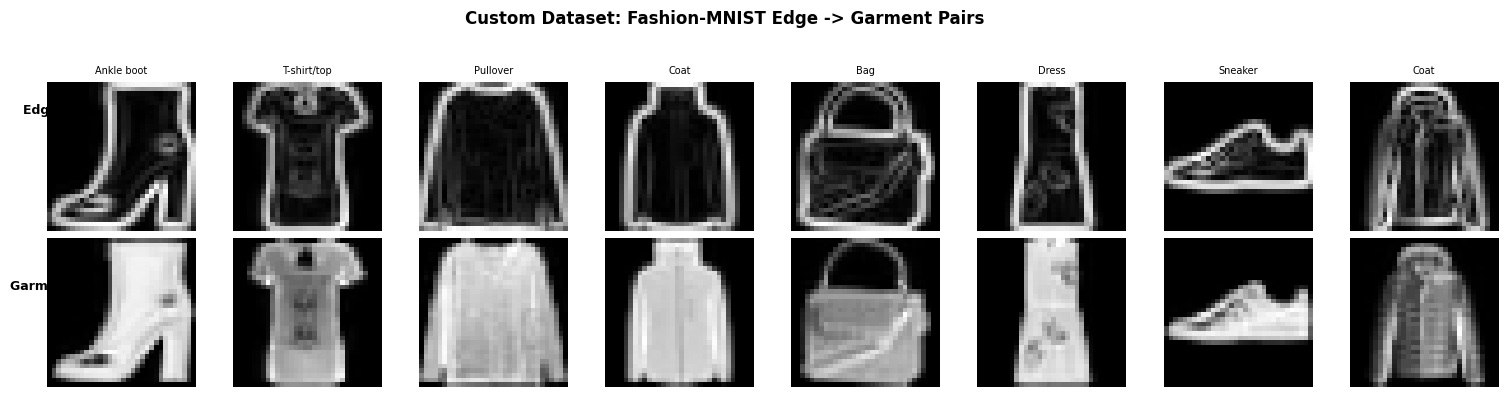

Saved project_dataset.png


In [2]:
# ── Build paired edge -> garment dataset from Fashion-MNIST ────────────────────
N_SAMPLES = 1500
N_EPOCHS = 8
BATCH_SIZE = 32
LAMBDA_L1 = 100
CLASS_NAMES = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

tf = transforms.Compose([transforms.Resize(32), transforms.ToTensor()])
fmnist = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=tf)
subset = Subset(fmnist, list(range(N_SAMPLES)))
loader = DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

def sobel_edges(x):
    kx = torch.tensor([[-1.,0.,1.],[-2.,0.,2.],[-1.,0.,1.]]).view(1,1,3,3)
    ky = kx.transpose(2,3)
    gx = F.conv2d(x, kx, padding=1)
    gy = F.conv2d(x, ky, padding=1)
    mag = torch.sqrt(gx**2 + gy**2 + 1e-8)
    mag = mag / mag.amax(dim=(2,3), keepdim=True).clamp(min=1e-6)
    return mag

xb, yb = next(iter(loader))
print(f'Fashion-MNIST paired dataset: {len(subset)} samples | classes: {len(CLASS_NAMES)} | size {tuple(xb.shape[2:])}')

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
edges_demo = sobel_edges(xb[:8])
for i in range(8):
    axes[0,i].imshow(edges_demo[i,0].numpy(), cmap='gray'); axes[0,i].axis('off')
    axes[0,i].set_title(CLASS_NAMES[yb[i]], fontsize=7)
    axes[1,i].imshow(xb[i,0].numpy(), cmap='gray'); axes[1,i].axis('off')
fig.text(0.08, 0.72, 'Edge (x)', ha='center', fontweight='bold', fontsize=9)
fig.text(0.08, 0.28, 'Garment (y)', ha='center', fontweight='bold', fontsize=9)
plt.suptitle('Custom Dataset: Fashion-MNIST Edge -> Garment Pairs', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0.06,0,1,0.95])
plt.savefig('project_dataset.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved project_dataset.png')

## Step 2: Model — U-Net-lite Generator + PatchGAN Discriminator

Same Pix2Pix architecture as Wednesday: an encoder-decoder generator with skip connections
(so fine spatial detail from the edge map reaches the output), and a PatchGAN discriminator that
scores local patches of the (input, output) pair rather than the whole image at once.


In [3]:
# ── Pix2Pix architecture (same recipe as Wednesday, new dataset) ──────────────
class UNetLiteGenerator(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=32):
        super().__init__()
        self.e1 = nn.Sequential(nn.Conv2d(in_ch, base, 4, 2, 1), nn.LeakyReLU(0.2))
        self.e2 = nn.Sequential(nn.Conv2d(base, base*2, 4, 2, 1), nn.BatchNorm2d(base*2), nn.LeakyReLU(0.2))
        self.e3 = nn.Sequential(nn.Conv2d(base*2, base*4, 4, 2, 1), nn.BatchNorm2d(base*4), nn.LeakyReLU(0.2))
        self.d1 = nn.Sequential(nn.ConvTranspose2d(base*4, base*2, 4, 2, 1), nn.BatchNorm2d(base*2), nn.ReLU())
        self.d2 = nn.Sequential(nn.ConvTranspose2d(base*4, base, 4, 2, 1), nn.BatchNorm2d(base), nn.ReLU())
        self.d3 = nn.ConvTranspose2d(base*2, out_ch, 4, 2, 1)

    def forward(self, x):
        e1 = self.e1(x); e2 = self.e2(e1); e3 = self.e3(e2)
        d1 = self.d1(e3)
        d2 = self.d2(torch.cat([d1, e2], dim=1))
        d3 = self.d3(torch.cat([d2, e1], dim=1))
        return torch.sigmoid(d3)

class PatchDiscriminator(nn.Module):
    def __init__(self, in_ch=2, base=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(base, base*2, 4, 2, 1), nn.BatchNorm2d(base*2), nn.LeakyReLU(0.2),
            nn.Conv2d(base*2, base*4, 4, 2, 1), nn.BatchNorm2d(base*4), nn.LeakyReLU(0.2),
            nn.Conv2d(base*4, 1, 4, 1, 1)
        )
    def forward(self, x, y):
        return self.net(torch.cat([x, y], dim=1))

G = UNetLiteGenerator().to(DEVICE)
D = PatchDiscriminator().to(DEVICE)
print(f'Generator params: {sum(p.numel() for p in G.parameters()):,}')
print(f'PatchGAN Discriminator params: {sum(p.numel() for p in D.parameters()):,}')

Generator params: 362,881
PatchGAN Discriminator params: 167,521


In [4]:
# ── Train Pix2Pix on the custom Fashion-MNIST edge->garment task ─────────────
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce = nn.BCEWithLogitsLoss()
l1  = nn.L1Loss()

history = {'d_loss': [], 'g_loss': [], 'l1_loss': []}
for epoch in range(N_EPOCHS):
    d_losses, g_losses, l1_losses = [], [], []
    for real_y, _ in loader:
        real_y = real_y.to(DEVICE)
        real_x = sobel_edges(real_y)

        with torch.no_grad():
            fake_y = G(real_x)
        d_real = D(real_x, real_y)
        d_fake = D(real_x, fake_y)
        d_loss = bce(d_real, torch.ones_like(d_real)) + bce(d_fake, torch.zeros_like(d_fake))
        opt_D.zero_grad(); d_loss.backward(); opt_D.step()

        fake_y = G(real_x)
        d_fake_for_g = D(real_x, fake_y)
        g_adv = bce(d_fake_for_g, torch.ones_like(d_fake_for_g))
        g_l1  = l1(fake_y, real_y)
        g_loss = g_adv + LAMBDA_L1 * g_l1
        opt_G.zero_grad(); g_loss.backward(); opt_G.step()

        d_losses.append(d_loss.item()); g_losses.append(g_adv.item()); l1_losses.append(g_l1.item())

    history['d_loss'].append(np.mean(d_losses))
    history['g_loss'].append(np.mean(g_losses))
    history['l1_loss'].append(np.mean(l1_losses))
    print(f'Epoch {epoch+1}/{N_EPOCHS} | D: {np.mean(d_losses):.3f} | G_adv: {np.mean(g_losses):.3f} | L1: {np.mean(l1_losses):.4f}')

Epoch 1/8 | D: 0.700 | G_adv: 1.640 | L1: 0.2335


Epoch 2/8 | D: 0.362 | G_adv: 2.557 | L1: 0.1227


Epoch 3/8 | D: 0.593 | G_adv: 2.098 | L1: 0.0894


Epoch 4/8 | D: 0.801 | G_adv: 1.611 | L1: 0.0760


Epoch 5/8 | D: 0.934 | G_adv: 1.375 | L1: 0.0668


Epoch 6/8 | D: 1.005 | G_adv: 1.242 | L1: 0.0624


Epoch 7/8 | D: 1.101 | G_adv: 1.127 | L1: 0.0584


Epoch 8/8 | D: 1.113 | G_adv: 1.069 | L1: 0.0548


## Step 3: Evaluate — Qualitative Results


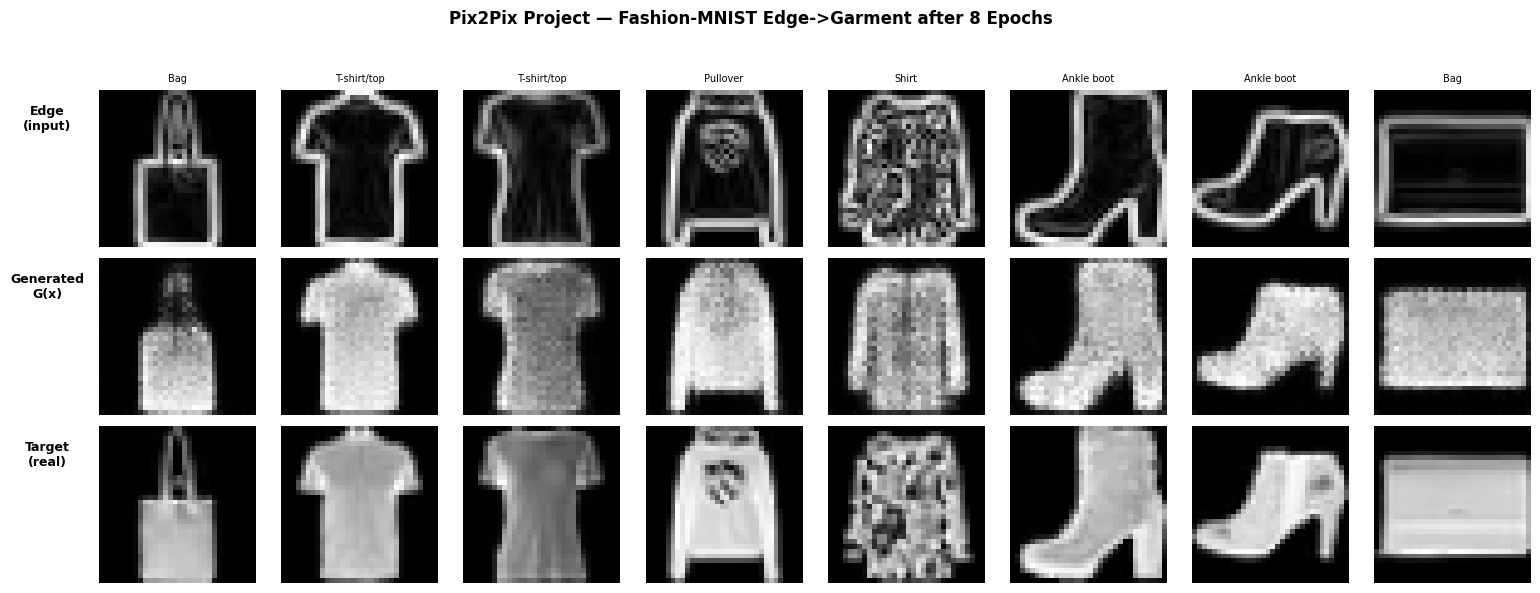

Saved project_results.png


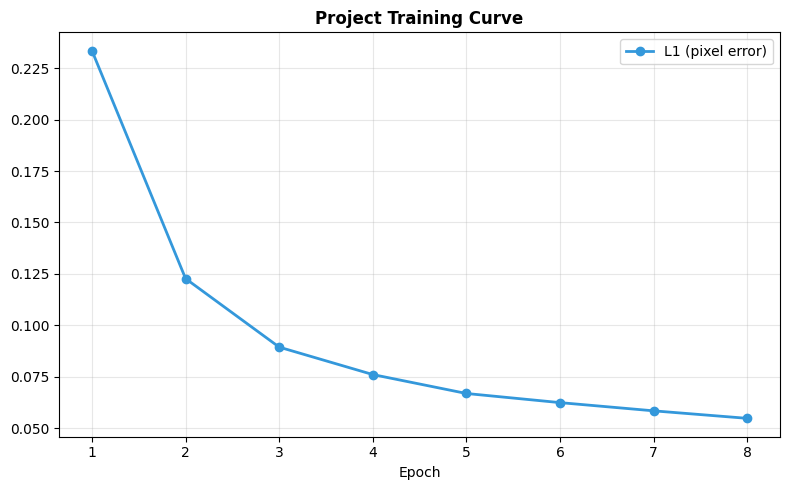

Saved project_training.png


In [5]:
# ── Results grid: edge -> generated -> target, across several classes ─────────
G.eval()
with torch.no_grad():
    sample_y, sample_labels = next(iter(loader))
    sample_y = sample_y[:8].to(DEVICE)
    sample_x = sobel_edges(sample_y)
    sample_fake = G(sample_x)

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i in range(8):
    axes[0,i].imshow(sample_x[i,0].cpu().numpy(), cmap='gray'); axes[0,i].axis('off')
    axes[0,i].set_title(CLASS_NAMES[sample_labels[i]], fontsize=7)
    axes[1,i].imshow(sample_fake[i,0].cpu().numpy(), cmap='gray'); axes[1,i].axis('off')
    axes[2,i].imshow(sample_y[i,0].cpu().numpy(), cmap='gray'); axes[2,i].axis('off')
fig.text(0.06, 0.78, 'Edge\n(input)', ha='center', fontweight='bold', fontsize=9)
fig.text(0.06, 0.5, 'Generated\nG(x)', ha='center', fontweight='bold', fontsize=9)
fig.text(0.06, 0.22, 'Target\n(real)', ha='center', fontweight='bold', fontsize=9)
plt.suptitle(f'Pix2Pix Project — Fashion-MNIST Edge->Garment after {N_EPOCHS} Epochs', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0.08,0,1,0.95])
plt.savefig('project_results.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved project_results.png')

fig, ax = plt.subplots(figsize=(8, 5))
ep = range(1, N_EPOCHS+1)
ax.plot(ep, history['l1_loss'], color='#3498db', lw=2, marker='o', label='L1 (pixel error)')
ax.set_xlabel('Epoch'); ax.set_title('Project Training Curve', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('project_training.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved project_training.png')

## Step 4: Gradio Demo

Wrap the trained generator in a `gradio.Interface`: the user sketches on a canvas, we Sobel-edge
the sketch (in case it isn't already a thin edge map) and feed it to `G`, which returns a
generated garment. `demo.launch(prevent_thread_lock=True)` starts a local server without blocking
this notebook, and we close it right after to confirm the demo runs end-to-end.


In [6]:
# ── Gradio demo wrapping the trained generator ─────────────────────────────────
import gradio as gr

def translate_sketch(sketch):
    """sketch: HxW or HxWx3/4 uint8 array from the Gradio canvas -> generated garment image."""
    if sketch is None:
        return np.zeros((32, 32), dtype=np.uint8)
    if sketch.ndim == 3:
        sketch = sketch.mean(axis=2)
    t = torch.tensor(sketch, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0
    t = F.interpolate(t, size=(32, 32), mode='bilinear', align_corners=False).to(DEVICE)
    edge = sobel_edges(t)
    with torch.no_grad():
        out = G(edge)[0, 0].cpu().numpy()
    return (out * 255).astype(np.uint8)

demo = gr.Interface(
    fn=translate_sketch,
    inputs=gr.Image(image_mode='L', label='Draw or upload a sketch'),
    outputs=gr.Image(image_mode='L', label='Generated garment (Pix2Pix)'),
    title='Image-to-Image Translation — Sketch to Garment (Pix2Pix)',
    description='Week 15 Friday project — U-Net generator trained on Fashion-MNIST edge->garment pairs.'
)

# Sanity-check the demo function directly (no server needed for this)
test_input = (sample_x[0,0].cpu().numpy() * 255).astype(np.uint8)
test_output = translate_sketch(test_input)
print(f'translate_sketch() OK | input {test_input.shape} -> output {test_output.shape}')

# Launch the actual Gradio server briefly to prove the interface itself works end-to-end
url = demo.launch(prevent_thread_lock=True, quiet=True, share=False, inbrowser=False)
print('Gradio demo launched locally.')
demo.close()
print('Gradio demo closed (this was a one-shot smoke test — run demo.launch() again to keep it open).')

translate_sketch() OK | input (32, 32) -> output (32, 32)


Gradio demo launched locally.
Closing server running on port: 7860
Gradio demo closed (this was a one-shot smoke test — run demo.launch() again to keep it open).


## Project Takeaways

| Concept | What I Learned |
|---------|-----------------|
| **Custom dataset** | Swapping MNIST for Fashion-MNIST required no architecture changes — Pix2Pix's edge→image recipe generalises directly to a new domain |
| **PatchGAN discriminator** | Still the right choice here — the classification difficulty (10 garment shapes vs 10 digit shapes) barely changes the discriminator's job |
| **L1 weight (λ=100)** | Dominates the loss early in training, giving the generator a strong low-frequency target before the adversarial term sharpens detail |
| **Gradio `Interface`** | `fn` + `inputs` + `outputs` is enough to wrap any trained PyTorch model as an interactive web demo — `launch(prevent_thread_lock=True)` lets it run without blocking a notebook |
| **End-to-end pipeline** | Data → paired-translation model → trained weights → interactive demo, all in one notebook, is the same shape as a real deployed Pix2Pix product |
